In [8]:
from langgraph.graph import START, END, StateGraph
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from dotenv import load_dotenv
import os

load_dotenv()

True

In [18]:
# llm
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL")

if not GROQ_API_KEY or not GROQ_MODEL:
    raise RuntimeError("GROQ_API_KEY / GROQ_MODEL missing from env")

llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [3]:
class SubState(TypedDict):
    input_text: str
    translate_text: str

In [19]:
def translate_text(state: SubState):
    prompt = f"""Translate the following text into Urdu. keep it natural and clear. Don't add extra content.\n\n
    
    Text:
    {state["input_text"].strip()}
    """
    
    translated_text = llm.invoke(prompt).content
    
    return {"translate_text": translated_text}

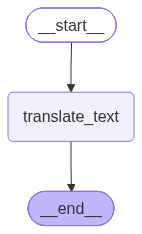

In [21]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()

subgraph

In [17]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [20]:
def generate_answer(state: ParentState):
    answer = llm.invoke(f"I would like you to act as a helpfull AI assistant and answer clearly.\n\nQuestion: {state["question"]}").content
    
    return {"answer_eng": answer}

In [22]:
def translate_answer(state: ParentState):
    
    # Call to subgraph
    result = subgraph.invoke({"input_text": state["answer_eng"]})
    
    return {"answer_urdu": result["translate_text"]}

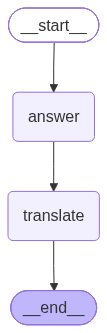

In [25]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, "answer")
parent_builder.add_edge("answer", "translate")
parent_builder.add_edge("translate", END)

workflow = parent_builder.compile()

workflow

In [27]:
initial_input = {"question": "What is a Quantum Physics? I woudl like you to explain it in simple wording."}
result = workflow.invoke(initial_input)

question = result["question"]
answer_eng = result["answer_eng"]
answer_urdu = result["answer_urdu"]
print(question)
print(answer_eng)
print(answer_urdu)

What is a Quantum Physics? I woudl like you to explain it in simple wording.
**Quantum physics (or quantum mechanics) is the part of science that explains how the tiniest pieces of the universe behave—things like atoms, electrons, photons (particles of light), and other sub‑atomic particles.**

### Why do we need it?
The everyday rules we’re used to—like a ball rolling in a straight line or a light switch being either on or off—work great for objects we can see and touch. But when we look at things that are millions of times smaller than a grain of sand, those “classical” rules stop working. Quantum physics gives us the correct rules for that tiny world.

### Core ideas in plain language

| Concept | What it means (simple terms) |
|---------|------------------------------|
| **Quantization** | Energy doesn’t come in any size you like; it comes in *chunks* (like LEGO bricks). An electron in an atom can only have certain specific energy levels, not anything in between. |
| **Wave‑particl